In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_forces)=
# Get forces

*Extracting atomic force vectors and scalar magnitudes from molecular mechanics force fields.*

The function {func}`molsysmt.molecular_mechanics.get_forces` evaluates the negative gradient of the potential energy with respect to atomic coordinates ($-\nabla U$).

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.molecular_mechanics.get_forces`.
:::


## Basic usage

Let's evaluate the 3D atomic force vectors acting on a peptide system:


In [2]:
import molsysmt as msm
import pyunitwizard as puw
import matplotlib.pyplot as plt
import numpy as np


In [3]:
molsys = msm.build.build_peptide('AceAlaCysAspGluPheNme')
context = msm.convert(molsys, to_form='openmm.Context')


We extract the 3D atomic force vectors:


In [4]:
forces = msm.molecular_mechanics.get_forces(context)
print('Forces shape (n_atoms, 3):', forces.shape)
print('First 5 atomic force vectors (kJ/(mol*nm)):\n', forces[:5])


Forces shape (n_atoms, 3): (80, 3)
First 5 atomic force vectors (kJ/(mol*nm)):
 [[179.88484549558262 41.70303530308277 -0.8973149008401462] [239.06626398847555 318.8881770458896 3.5266120432751507] [14.497446351112472 -34.71303520914195 -43.75043171909528] [16.21916479697837 -33.60863295111473 41.396873514124856] [-389.692271859539 -151.45859643899843 232.40997589083193]] kilojoule / mole / nanometer


## Force magnitudes and residue profiles

Setting `magnitude=True` calculates the scalar Euclidean norm of the forces ($\|\mathbf{F}_i\|$) for each atom:


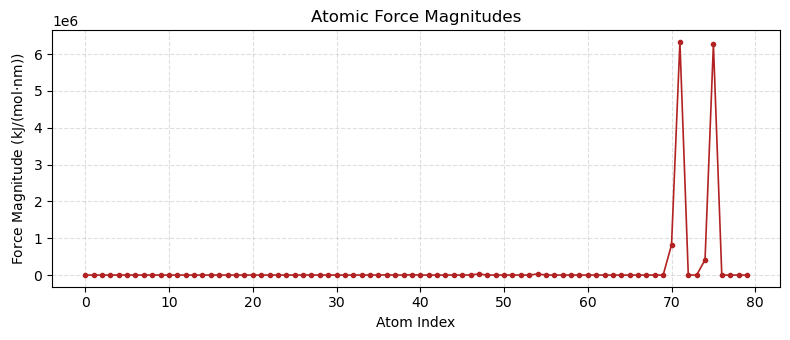

In [5]:
force_mags = msm.molecular_mechanics.get_forces(context, magnitude=True)
mag_vals = puw.get_value(force_mags, to_unit='kJ/(mol*nm)')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(len(mag_vals)), mag_vals, color='firebrick', marker='o', markersize=3, linewidth=1.2)
ax.set_title('Atomic Force Magnitudes')
ax.set_xlabel('Atom Index')
ax.set_ylabel('Force Magnitude (kJ/(mol$\cdot$nm))')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Build peptide <Tutorial_Build_peptide>`: Construct peptide models with {func}`molsysmt.build.build_peptide`.
- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems with {func}`molsysmt.basic.convert`.
- {ref}`Potential energy minimization <Tutorial_Potential_energy_minimization>`: Minimize potential energy with {func}`molsysmt.molecular_mechanics.potential_energy_minimization`.
:::
